# Course NIGK21007U - Integrated Water Resources Modelling
## Reading and Processing res1d files

res1d is a proprietary binary file format by DHI. It is used to store results of 1-dimensional hydrodynamic simulations. Datasets generally have 2 dimensions, i.e. time and chainage (= distance along the river). This notebook shows you how to read and process such files in python.

First, import all necessary python packages:

In [1]:
from mikeio1d import Res1D
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

mikeio1d is a python library made by DHI that enables interaction with res1d file format. matplotlib is a plotting and visualization package. 

Next, specify the name of the res1d file you want to read. **r'...'** makes sure that the filename is read as a raw string and backslashes are not interpreted as line breaks. Obviously, you need to adjust path and file name so that they point to an existing dfs3 file on your system.

In [2]:
file_path = r'c:\Users\vpk410\Documents\DK1\DK1_HIPmodels\Setup\DK1_HIP_500m_mh.mhydro - Result Files\DK1_HIP_mh_500m.res1d'

Next, open the file to get a res1d object. After this step, metadata is available but data isn't loaded yet.

In [3]:
res = Res1D(file_path)
data = res.read()


Inspect available items in the file:

In [4]:
all_keys = data.keys()
print(all_keys)

Index(['LateralInflowSheOl2Node:'TUDE_AA_DK1', -8388',
       'LateralInflowSheSz2Node:'TUDE_AA_DK1', -8388',
       'LateralInflowSheOl2Node:'TUDE_AA_DK1', 32800',
       'LateralInflowSheSz2Node:'TUDE_AA_DK1', 32800',
       'LateralInflowSheOl2Node:'AAMOSE_AA_DK1', -11813',
       'LateralInflowSheSz2Node:'AAMOSE_AA_DK1', -11813',
       'LateralInflowSheOl2Node:'SUSAA_DK1', -5693',
       'LateralInflowSheSz2Node:'SUSAA_DK1', -5693',
       'LateralInflowSheOl2Node:'OVRE_SUSAA_DK1', 0',
       'LateralInflowSheSz2Node:'OVRE_SUSAA_DK1', 0',
       ...
       'LateralInflowSHESatZoneDrain:VRAABYAA_DK1:-7834.5',
       'LateralInflowSHESatZoneDrain:VRAABYAA_DK1:-7368',
       'LateralInflowSHESatZoneDrain:VRAABYAA_DK1:-6901.5',
       'LateralInflowSHESatZoneDrain:VRAABYAA_DK1:-6435',
       'LateralInflowSHESatZoneDrain:VRAABYAA_DK1:-5968.67',
       'LateralInflowSHESatZoneDrain:VRAABYAA_DK1:-5502.33',
       'LateralInflowSHESatZoneDrain:VRAABYAA_DK1:-5036',
       'LateralInflowSH

You can see that items are generally organized by flow quantity, river, chainage. Define what you want to see:

In [5]:
target_variable = "WaterLevel"
#target_variable = "Discharge"
target_reach = "TUDE_AA"
#target_unit = 'm^3/s'
target_unit = 'mamsl'

Select the items and print a list:

In [6]:
selected_keys = [
    key for key in all_keys 
    if target_variable in key and target_reach in key
]

# Print the resulting list
print(f"--- {target_variable} Keys for {target_reach} ---")
for key in selected_keys:
    print(key)

--- WaterLevel Keys for TUDE_AA ---
WaterLevel:TUDE_AA_DK1:-8388
WaterLevel:TUDE_AA_DK1:-7960.8
WaterLevel:TUDE_AA_DK1:-7533.6
WaterLevel:TUDE_AA_DK1:-7106.4
WaterLevel:TUDE_AA_DK1:-6679.2
WaterLevel:TUDE_AA_DK1:-6252
WaterLevel:TUDE_AA_DK1:-6252
WaterLevel:TUDE_AA_DK1:-5767.33
WaterLevel:TUDE_AA_DK1:-5282.67
WaterLevel:TUDE_AA_DK1:-4798
WaterLevel:TUDE_AA_DK1:-4798
WaterLevel:TUDE_AA_DK1:-4422.33
WaterLevel:TUDE_AA_DK1:-4046.67
WaterLevel:TUDE_AA_DK1:-3671
WaterLevel:TUDE_AA_DK1:-3671
WaterLevel:TUDE_AA_DK1:-3205.5
WaterLevel:TUDE_AA_DK1:-2740
WaterLevel:TUDE_AA_DK1:-2740
WaterLevel:TUDE_AA_DK1:-2355.25
WaterLevel:TUDE_AA_DK1:-1970.5
WaterLevel:TUDE_AA_DK1:-1585.75
WaterLevel:TUDE_AA_DK1:-1201
WaterLevel:TUDE_AA_DK1:-1201
WaterLevel:TUDE_AA_DK1:-724.75
WaterLevel:TUDE_AA_DK1:-248.5
WaterLevel:TUDE_AA_DK1:227.75
WaterLevel:TUDE_AA_DK1:704
WaterLevel:TUDE_AA_DK1:986.5
WaterLevel:TUDE_AA_DK1:1269
WaterLevel:TUDE_AA_DK1:1269
WaterLevel:TUDE_AA_DK1:1727.5
WaterLevel:TUDE_AA_DK1:2186
WaterL

Select the chainage of interest:

In [7]:
target_chainage = '32800'

Find the time series for that chainage:

In [8]:
# Find the exact column name
target_column_name = None
for key in all_keys:
    # Check if the key contains both the variable and the chainage
    if target_variable in key and target_chainage in key:
        target_column_name = key
        break # Stop searching once found

if target_column_name:
    print(f"Found column: {target_column_name}")
else:
    print(f"Error: Could not find column for {target_variable} at chainage {target_chainage}")

Found column: WaterLevel:TUDE_AA_DK1:32800


Make a time series plot:

<Axes: title={'center': 'WaterLevel Time Series at Chainage 32800'}, xlabel='Time', ylabel='WaterLevel (mamsl)'>

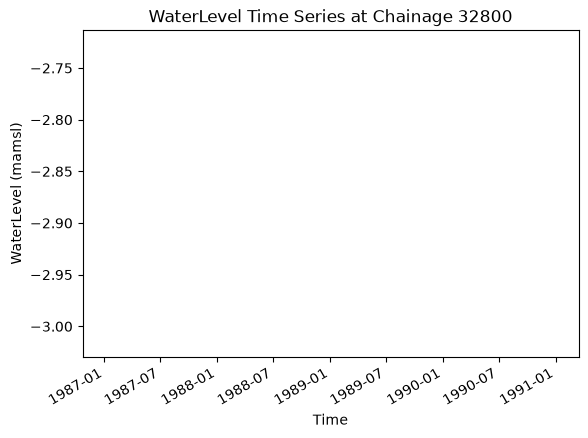

In [9]:
time_series_data = data[target_column_name]
    
# Plotting is easy since the index (x-axis) is already the timestamps
time_series_data.plot(
    title=f'{target_variable} Time Series at Chainage {target_chainage}',
    xlabel='Time',
    ylabel=f'{target_variable}' +' (' + target_unit + ')' # You'll need to fill in the correct unit!
)

Make a profile plot. First define time stamp of interest:

In [10]:
target_time = '1989-01-02 06:00:00'

Next, select the time slice, and keep only the selected target variable and target reach:

In [11]:
# Select the row (time slice)
profile_series = data.loc[target_time] 

# Filter the series to keep only columns for the TARGET VARIABLE AND TARGET REACH
# This uses the same list comprehension logic but applied to the index:
water_level_profile = profile_series[
    profile_series.index.str.contains(target_variable) & 
    profile_series.index.str.contains(target_reach)
]

print(f"Data points selected for {target_reach} at {target_time}: {len(water_level_profile)}")

Data points selected for TUDE_AA at 1989-01-02 06:00:00: 114


Extract the chainage of different data points:

In [12]:
# Extract the Chainage from the column names (the last value separated by ':')
# Note: This assumes the chainage is always the last item after the final colon.
try:
    chainage_values = pd.to_numeric(
        water_level_profile.index.str.split(':').str[-1]
    )
except ValueError:
    print("Error: Could not convert chainage values to numeric. Check data format.")
    chainage_values = np.arange(len(water_level_profile)) # Use simple index as fallback

Create a new DataFrame using the extracted chainage as the index:

In [13]:
plot_df = pd.DataFrame({
    target_variable: water_level_profile.values
}, index=chainage_values)

Sort by chainage (index) to ensure the profile line is drawn correctly:

In [14]:
plot_df.index.name = 'Chainage (m)'
plot_df = plot_df.sort_index()

Make the plot

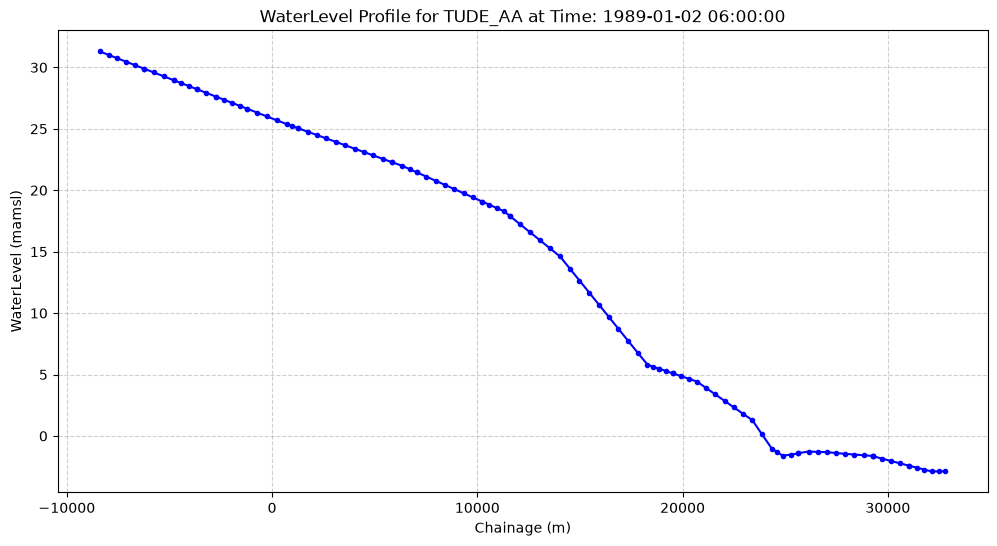

In [15]:
plt.figure(figsize=(12, 6))
plot_df[target_variable].plot(
    marker='o',
    linestyle='-',
    markersize=3,
    color='b'
)

# Add titles and labels
plt.title(target_variable + f' Profile for {target_reach} at Time: {target_time}')
plt.xlabel('Chainage (m)')
plt.ylabel(f'{target_variable}' +' (' + target_unit + ')' )
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()